In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

# Load feature table
df = pd.read_csv('../data/processed/feature_table.csv')

# Define feature columns
feature_cols = ['gnomad_exome_af', 'cadd_phred', 'clinvar_pathogenic',
                'activity_enc', 'domain_Catalytic', 'domain_Extracellular',
                'domain_Prodomain']

# Split your feature table by gene
ldlr_data = df[df['gene'] == 'LDLR'].copy()
pcsk9_data = df[df['gene'] == 'PCSK9'].copy()
apob_data = df[df['gene'] == 'APOB'].copy()

print(f'LDLR rows: {len(ldlr_data)}')
print(f'PCSK9 rows: {len(pcsk9_data)}')
print(f'APOB rows: {len(apob_data)}')

# Train ONLY on LDLR + benign examples
train_data = df[df['gene'].isin(['LDLR', 'APOB'])].copy()
# Add benign rows
train_data = pd.concat([train_data, df[df['fh_label'] == 0]], ignore_index=True)

X_train = train_data[feature_cols].fillna(0)
y_train = train_data['fh_label']

print(f'\nTraining set class distribution:\n{y_train.value_counts()}')

# Fit logistic regression on LDLR/APOB data
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

# Now apply the trained model to PCSK9 variants as validation
X_pcsk9 = pcsk9_data[feature_cols].fillna(0)
pcsk9_predictions = lr.predict_proba(X_pcsk9)[:, 1]

pcsk9_data = pcsk9_data.copy()
pcsk9_data['predicted_fh_risk'] = pcsk9_predictions
print('\nPCSK9 variant risk scores:')
print(pcsk9_data[['variant', 'activity_type', 'predicted_fh_risk']])

LDLR rows: 149
PCSK9 rows: 8
APOB rows: 3

Training set class distribution:
fh_label
1    146
0     16
Name: count, dtype: int64

PCSK9 variant risk scores:
        variant activity_type  predicted_fh_risk
0         D374Y           GOF       2.857662e-01
1         S127R           GOF       9.877619e-01
2         F216L           GOF       9.838420e-01
3         R218S           GOF       9.838420e-01
150  rs11591147           LOF       6.177715e-09
153    rs562556           LOF       1.378204e-06
156   rs2479409           LOF       2.041221e-02
159   rs7552841           LOF       7.683272e-02


Random Forest AUC: 1.000 (+/- 0.000)

PCSK9 variant risk scores (Random Forest):
        variant activity_type  predicted_fh_risk  rf_predicted_fh_risk
0         D374Y           GOF       2.857662e-01                  0.47
1         S127R           GOF       9.877619e-01                  0.81
2         F216L           GOF       9.838420e-01                  0.76
3         R218S           GOF       9.838420e-01                  0.76
150  rs11591147           LOF       6.177715e-09                  0.00
153    rs562556           LOF       1.378204e-06                  0.00
156   rs2479409           LOF       2.041221e-02                  0.00
159   rs7552841           LOF       7.683272e-02                  0.00


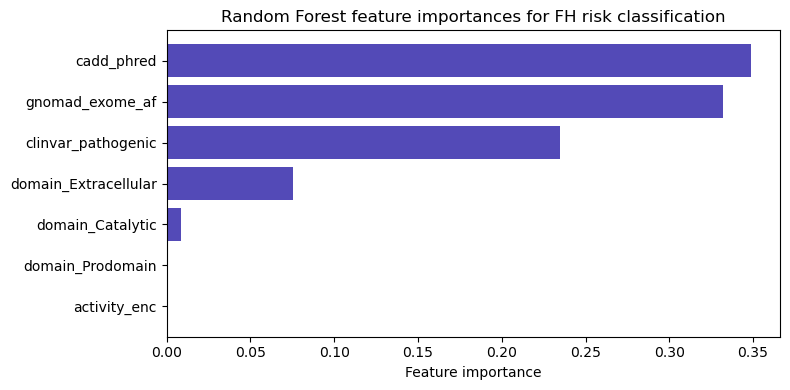


Feature importances:
                feature  importance
1            cadd_phred    0.348607
0       gnomad_exome_af    0.332145
2    clinvar_pathogenic    0.234616
5  domain_Extracellular    0.075587
4      domain_Catalytic    0.008478
6      domain_Prodomain    0.000567
3          activity_enc    0.000000


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt

# Train Random Forest on same LDLR/APOB training data
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc')

print(f'Random Forest AUC: {rf_scores.mean():.3f} (+/- {rf_scores.std():.3f})')

# Fit on full training data
rf.fit(X_train, y_train)

# Apply to PCSK9 variants as validation
pcsk9_rf_predictions = rf.predict_proba(X_pcsk9)[:, 1]
pcsk9_data['rf_predicted_fh_risk'] = pcsk9_rf_predictions

print('\nPCSK9 variant risk scores (Random Forest):')
print(pcsk9_data[['variant', 'activity_type', 'predicted_fh_risk', 'rf_predicted_fh_risk']])

# Feature importances plot
imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(imp_df['feature'], imp_df['importance'], color='#534AB7')
plt.xlabel('Feature importance')
plt.title('Random Forest feature importances for FH risk classification')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../results/feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFeature importances:')
print(imp_df)

In [8]:
print("=== PCSK9 Validation Results ===")
print()
print("GOF variants (should score HIGH):")
gof = pcsk9_data[pcsk9_data['activity_type'] == 'GOF'][['variant', 'predicted_fh_risk']]
for _, row in gof.iterrows():
    risk_pct = row['predicted_fh_risk'] * 100
    flag = "HIGH RISK" if row['predicted_fh_risk'] > 0.5 else "MODERATE RISK"
    print(f"  {row['variant']}: {risk_pct:.1f}% — {flag}")

print()
print("Benign variants (should score LOW):")
lof = pcsk9_data[pcsk9_data['activity_type'] == 'LOF'][['variant', 'predicted_fh_risk']]
for _, row in lof.iterrows():
    risk_pct = row['predicted_fh_risk'] * 100
    flag = "correctly classified as low risk" if row['predicted_fh_risk'] < 0.1 else "borderline"
    print(f"  {row['variant']}: {risk_pct:.2f}% — {flag}")

=== PCSK9 Validation Results ===

GOF variants (should score HIGH):
  D374Y: 28.6% — MODERATE RISK
  S127R: 98.8% — HIGH RISK
  F216L: 98.4% — HIGH RISK
  R218S: 98.4% — HIGH RISK

Benign variants (should score LOW):
  rs11591147: 0.00% — correctly classified as low risk
  rs562556: 0.00% — correctly classified as low risk
  rs2479409: 2.04% — correctly classified as low risk
  rs7552841: 7.68% — correctly classified as low risk


## Proposed Blood Test Panel for FH Diagnosis

Based on the variant-activity analysis and classifier feature importances,
the following panel is proposed:

1. **PCSK9 gene sequencing**: Target exons encoding the catalytic domain
   (residues 153-451) and the prodomain (residues 31-152).
   Flag variants classified as Pathogenic in ClinVar AND with gnomAD AF < 0.001.

2. **LDLR gene sequencing**: Full coding sequence. Over 2,000 pathogenic
   variants documented. Flag any Pathogenic/Likely Pathogenic ClinVar entry.

3. **APOB targeted sequencing**: Focus on the LDL receptor binding domain
   (exon 26, codon 3527). R3527Q/W are the primary FH-causing variants.

4. **Plasma PCSK9 level** (if ELISA available): Elevated plasma PCSK9
   (>300 ng/mL) combined with GOF variant detection strengthens the diagnosis.

**Risk score interpretation**: A patient carrying a pathogenic PCSK9 GOF variant
(CADD >25, gnomAD AF <0.001) scores as HIGH RISK. Carry the output of the
classifier as an adjunct to clinical LDL-C measurement and the Dutch Lipid
Clinic Network score.